# Dutch Card Transaction Hackathon


This dataset contains **~1M fully 100% synthetic Dutch card transactions** from July-December 2025. No real user data, no real merchant names, no real transaction IDs - everything is fabricated. Because it is synthetic, it **can and does contain mistakes, weird values, impossible combinations, and artifacts**. Treat it accordingly.

**Quick facts:**
- ~1,000,000 transactions from ~18,000 synthetic users across the Netherlands
- 7 transaction types, 3 states, 28 columns covering amounts, merchants, cards, and user demographics
- 3 labelled fraud scenario patterns are included in the data (see `is_fraud_scenario` column)
- All amounts are in GBP

### How This Data Was Generated

1. **Statistical profile extraction**: Aggregated patterns (averages, distributions, frequency tables, conditional probabilities) were extracted from ~94M real Dutch card transactions. These are just numbers — no personal data.
2. **Programmatic generation**: A custom generator creates entirely fake transactions from those statistical summaries. It uses:
   - GMM-driven behavioral clusters for coherent user spending profiles
   - Synthetic merchant catalog with controlled-grammar Dutch names + legal suffixes (B.V., V.O.F., etc.)
   - CPT-based card attribute generation (card type, entry method, brand, digital wallet)
   - Inverse-CDF amount sampling from per-MCC quantile profiles + Pareto tail extrapolation
   - Refund-after-purchase mechanism and subscription billing patterns
3. **Zero real identifiers**: No real merchant names, user IDs, or timestamps ever enter or leave the generator. All UUIDs are randomly generated.

No raw data was used during generation — only pre-computed statistical summaries.


## Data Dictionary

| Column | Type | Description |
|--------|------|-------------|
| `transaction_id` | str | Unique transaction identifier |
| `owner_id` | str | Synthetic user identifier (random UUID) |
| `type` | str | Transaction type: CARD_PAYMENT, ATM, CARD_REFUND, FEE, CHARGE, CARD_CREDIT, CARD_CHARGEBACK |
| `state` | str | Transaction state: COMPLETED, DECLINED, REVERTED |
| `txn_amount_gbp` | float | Transaction amount in GBP (positive=debit, negative=credit) |
| `bill_amount_gbp` | float | Billed amount in GBP (includes FX markup) |
| `fee_amount_gbp` | float | Transaction fee in GBP (0 for 94.7% of rows) |
| `txn_currency` | str | Transaction currency code (EUR, USD, GBP, etc.) |
| `txn_currency_type` | str | Always "FIAT" |
| `created_date` | datetime | Transaction creation timestamp |
| `updated_date` | datetime | Last update timestamp |
| `completed_date` | datetime | Completion timestamp (null for DECLINED/REVERTED) |
| `card_type` | str | Card type: physical, virtual, disposable |
| `card_brand` | str | Card brand: VISA, MASTERCARD, MAESTRO |
| `entry_method` | str | Entry method: CONTACTLESS--XPAY, ECOMMERCE, CARD_ON_FILE, CHIP, CONTACTLESS, OTHER, MAGSTRIPE, MOTO |
| `digitized_provider` | str | Digital wallet: APPLE_PAY, GOOGLE_PAY, Not digitized |
| `card_location` | str | DOMESTIC (NL merchant), INTER, Not PRESENT |
| `merchant_country` | str | Merchant country code (NL, IE, PL, GB, etc.) |
| `mcc` | str | Merchant Category Code (4-digit, e.g., 5411=grocery) |
| `category` | str | MCC description |
| `transaction_merchants_name` | str | Merchant name (synthetic) |
| `transaction_merchants_code` | str | Merchant code (synthetic) |
| `app_is_ecommerce` | bool | Whether transaction is via e-commerce |
| `age_group` | str | User age group: 18-24, 25-34, 35-44, 45-54, 55-64, 65-74, 75+ |
| `gender` | str | User gender: M, F |
| `region` | str | Dutch region name |
| `declined_reason_category` | str | Reason for decline (e.g., INSUFFICIENT_BALANCE) |
| `is_fraud_scenario` | str | Fraud scenario label (velocity_attack, impossible_travel, smurfing) or null |

### Key Concepts

- **CARD_PAYMENT**: 97% of transactions. This is the main type you will work with. The other types (ATM, FEE, CHARGE, etc.) have fewer merchant fields.
- **DECLINED**: ~17% of transactions are declined. The `declined_reason_category` column tells you why (only for declined transactions).
- **DOMESTIC vs INTER**: `card_location` tells you whether the merchant is in the Netherlands (DOMESTIC) or abroad (INTER). "Not PRESENT" means the card was not physically present (online/remote).
- **MCC codes**: 4-digit Merchant Category Codes that classify the merchant type. For example: 5411 = Grocery Stores, 5812 = Eating Places, 5735 = Music Stores


In [1]:

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

import os
import uuid

DATA_DIR = 'output'

for tier in [1_000_000, 250_000, 50_000, 10_000, 5_000]:
    path = os.path.join(DATA_DIR, f'synthetic_{tier}.parquet')
    if os.path.exists(path):
        df = pd.read_parquet(path)
        print(f"Loaded {path}  -->  {len(df):,} rows")
        break
else:
    raise FileNotFoundError("No parquet files found in output/")

# Ensure clean schema: add transaction_id if missing, drop internal columns
if 'transaction_id' not in df.columns:
    df['transaction_id'] = [str(uuid.uuid4()) for _ in range(len(df))]
    print("Added transaction_id column")

internal_cols = [c for c in ['cluster', 'digital_pref', 'domestic_ratio', 'merchant_id',
                              'merchant_name', 'merchant_code', 'is_subscription_event'] if c in df.columns]
if internal_cols:
    df.drop(columns=internal_cols, inplace=True)
    print(f"Dropped internal columns: {internal_cols}")

# Load the merchant catalog
catalog_path = os.path.join(DATA_DIR, 'synthetic_merchant_catalog.parquet')
if os.path.exists(catalog_path):
    merchants = pd.read_parquet(catalog_path)
    print(f"Loaded merchant catalog: {len(merchants):,} merchants")
else:
    merchants = None
    print("Merchant catalog not found (non-critical)")

# Convert datetime columns
for col in ['created_date', 'updated_date', 'completed_date']:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col])

print(f"\nShape: {df.shape}")
print(f"\nData types:\n{df.dtypes}")
print(f"\nFirst 5 rows:")
df.head()


Loaded output/synthetic_1000000.parquet  -->  1,000,000 rows
Loaded merchant catalog: 6,890 merchants

Shape: (1000000, 28)

Data types:
type                                     str
owner_id                                 str
age_group                                str
gender                                   str
region                                   str
mcc                                      str
category                                 str
merchant_country                         str
transaction_merchants_name               str
transaction_merchants_code               str
card_type                                str
entry_method                             str
card_brand                               str
digitized_provider                       str
card_location                            str
state                                    str
declined_reason_category                 str
app_is_ecommerce                      object
txn_amount_gbp                       float64
created_

,type,owner_id,age_group,gender,region,mcc,category,merchant_country,transaction_merchants_name,transaction_merchants_code,...,txn_amount_gbp,created_date,updated_date,completed_date,txn_currency,txn_currency_type,bill_amount_gbp,fee_amount_gbp,is_fraud_scenario,transaction_id
0,CARD_PAYMENT,000151e6-0ae2-48f8-bda5-3bd6d22448a1,25-34,M,Noord-Holland,4121,Taxicabs and Limousines,GR,RET 12,783728579916180,...,9.91,2025-07-06 08:36:19.000000,2025-07-06 20:29:28.712353,2025-07-06 09:09:34.020101,NZD,FIAT,9.89,0.0,NaN,4fd7f5b6-f942-401a-bd8a-28e915c2bc63
1,CARD_PAYMENT,000151e6-0ae2-48f8-bda5-3bd6d22448a1,25-34,M,Noord-Holland,7995,"Betting (including Lottery Tickets, Casino Gam...",NL,Zilveren Winkel Eenmanszaak,124781320830801,...,131.99,2025-07-06 11:40:54.992582,2025-07-07 07:47:56.829091,2025-07-06 14:03:20.589713,EUR,FIAT,132.14,0.0,NaN,decb70e9-3230-4cea-b3d0-c5877cfcdfb9
2,CARD_REFUND,000151e6-0ae2-48f8-bda5-3bd6d22448a1,25-34,M,Noord-Holland,4121,Taxicabs and Limousines,GR,RET 12,783728579916180,...,-9.91,2025-07-08 08:36:19.000000,2025-07-08 13:15:06.217499,2025-07-08 08:40:08.000000,EUR,FIAT,-9.91,0.0,NaN,0a84b6a2-d378-4d5e-a020-f17f7a59c91e
3,CARD_PAYMENT,000151e6-0ae2-48f8-bda5-3bd6d22448a1,NaN,M,Noord-Holland,5411,"Grocery Stores, Supermarkets",NL,Markt Zoetermeer B.V.,471742205970564,...,5.00,2025-07-09 11:04:27.498306,2025-07-10 17:15:42.313695,2025-07-09 13:31:14.167529,EUR,FIAT,4.95,0.0,NaN,81445e57-348e-4cde-8c5f-09637d86eab9
4,CARD_PAYMENT,000151e6-0ae2-48f8-bda5-3bd6d22448a1,25-34,M,Noord-Holland,5541,Service Stations ( with or without ancillary s...,FR,Tankstation Grote,836808073012560,...,5.72,2025-07-09 15:04:52.066889,2025-07-09 19:28:04.955522,2025-07-09 17:24:57.232302,EUR,FIAT,5.77,0.0,NaN,8c151ea5-146c-44d7-81bb-21ed14b77366


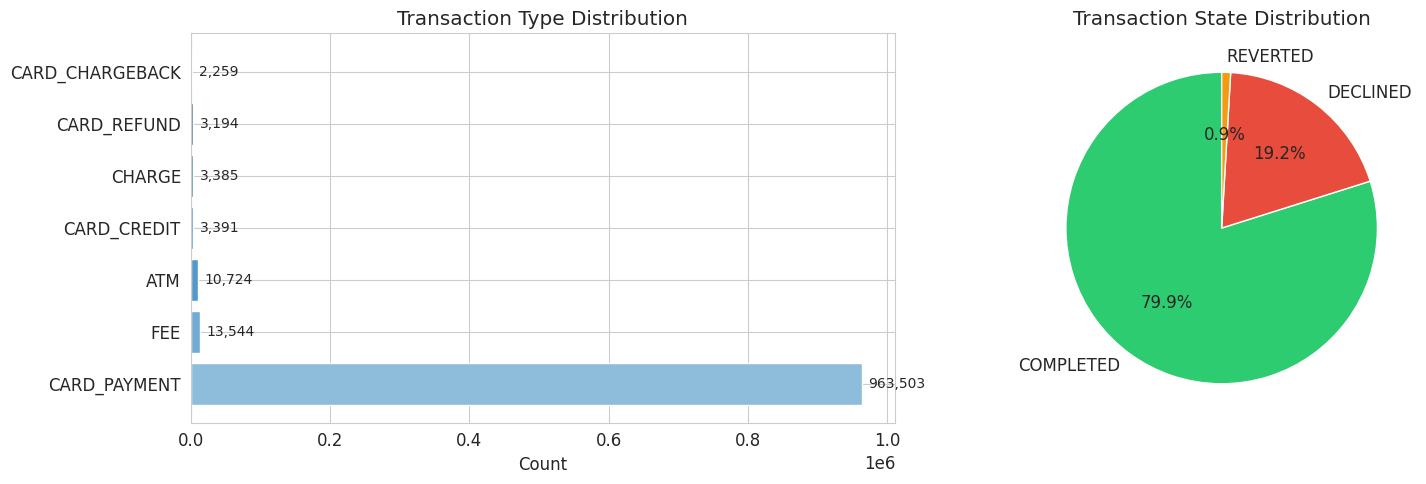

Date range: 2025-07-01 00:00:04  to  2025-12-31 23:59:55.862247
Unique users: 17,841
Unique merchants: 2,337

Amount statistics (GBP):
count    1000000.000000
mean          24.398978
std          149.866853
min        -1952.330000
25%            5.350000
50%            9.140000
75%           19.160000
max        54478.090000


In [2]:

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Transaction type distribution
type_counts = df['type'].value_counts()
axes[0].barh(type_counts.index, type_counts.values, color=sns.color_palette("Blues_d", len(type_counts)))
axes[0].set_title('Transaction Type Distribution')
axes[0].set_xlabel('Count')
for i, v in enumerate(type_counts.values):
    axes[0].text(v + type_counts.values[0]*0.01, i, f'{v:,}', va='center', fontsize=10)

# State distribution (pie chart)
state_counts = df['state'].value_counts()
colors = ['#2ecc71', '#e74c3c', '#f39c12']
axes[1].pie(state_counts.values, labels=state_counts.index, autopct='%1.1f%%',
            colors=colors[:len(state_counts)], startangle=90)
axes[1].set_title('Transaction State Distribution')

plt.tight_layout()
plt.show()

# Key stats
print(f"Date range: {df['created_date'].min()}  to  {df['created_date'].max()}")
print(f"Unique users: {df['owner_id'].nunique():,}")
print(f"Unique merchants: {df['transaction_merchants_name'].nunique():,}")
print(f"\nAmount statistics (GBP):")
print(df['txn_amount_gbp'].describe().to_string())


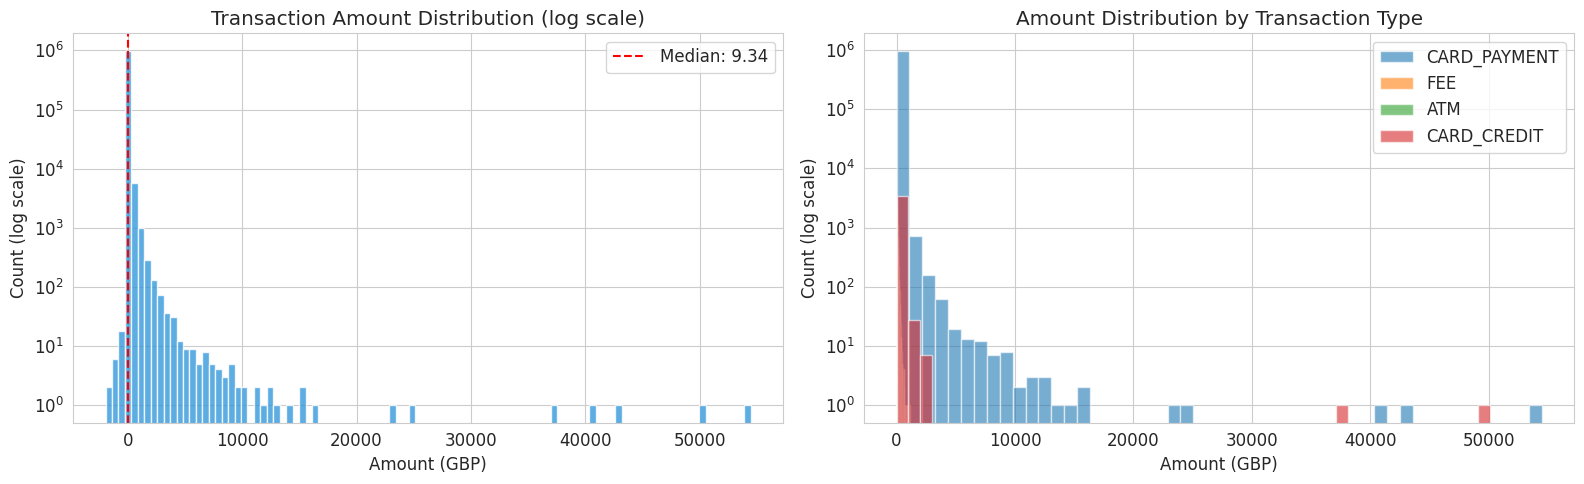

Amount statistics by transaction type:


,count,mean,median,std,min,max
type,,,,,,
ATM,10724,69.74,50.39,66.44,10.00,1108.48
CARD_CHARGEBACK,2259,73.29,24.00,168.72,0.12,2418.27
CARD_CREDIT,3391,98.35,14.56,1088.74,5.28,50137.67
CARD_PAYMENT,963503,24.11,9.22,137.62,0.01,54478.09
CARD_REFUND,3194,-23.05,-9.02,77.65,-1952.33,-0.01
CHARGE,3385,0.00,0.00,0.00,0.00,0.00
FEE,13544,0.02,0.00,0.19,0.00,10.89


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Log-scale histogram of all amounts
amounts = df['txn_amount_gbp']
amounts_nonzero = amounts[amounts != 0]
axes[0].hist(amounts_nonzero, bins=100, color='#3498db', edgecolor='white', alpha=0.8)
axes[0].set_yscale('log')
axes[0].set_title('Transaction Amount Distribution (log scale)')
axes[0].set_xlabel('Amount (GBP)')
axes[0].set_ylabel('Count (log scale)')
axes[0].axvline(amounts_nonzero.median(), color='red', linestyle='--',
                label=f'Median: {amounts_nonzero.median():.2f}')
axes[0].legend()

# Amount distribution by top transaction types
top_types = df['type'].value_counts().head(4).index.tolist()
for t in top_types:
    subset = df[(df['type'] == t) & (df['txn_amount_gbp'] != 0)]['txn_amount_gbp']
    if len(subset) > 0:
        axes[1].hist(subset, bins=50, alpha=0.6, label=t, edgecolor='white')
axes[1].set_yscale('log')
axes[1].set_title('Amount Distribution by Transaction Type')
axes[1].set_xlabel('Amount (GBP)')
axes[1].set_ylabel('Count (log scale)')
axes[1].legend()

plt.tight_layout()
plt.show()

# Amount statistics by type
print("Amount statistics by transaction type:")
df.groupby('type')['txn_amount_gbp'].agg(['count', 'mean', 'median', 'std', 'min', 'max']).round(2)



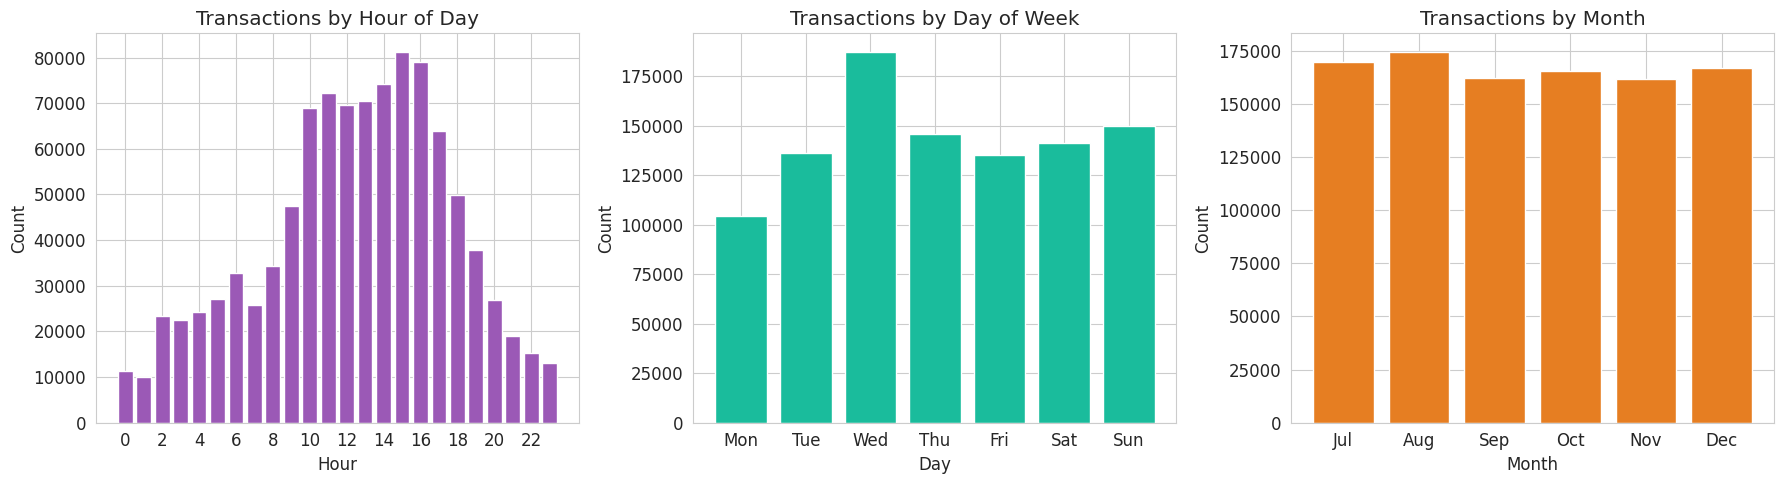

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Hour-of-day distribution
hour_counts = df['created_date'].dt.hour.value_counts().sort_index()
axes[0].bar(hour_counts.index, hour_counts.values, color='#9b59b6', edgecolor='white')
axes[0].set_title('Transactions by Hour of Day')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('Count')
axes[0].set_xticks(range(0, 24, 2))

# Day-of-week distribution
day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
day_counts = df['created_date'].dt.dayofweek.value_counts().sort_index()
axes[1].bar(range(7), day_counts.reindex(range(7), fill_value=0).values,
            color='#1abc9c', edgecolor='white')
axes[1].set_title('Transactions by Day of Week')
axes[1].set_xlabel('Day')
axes[1].set_ylabel('Count')
axes[1].set_xticks(range(7))
axes[1].set_xticklabels(day_names)

# Monthly volume
month_counts = df['created_date'].dt.month.value_counts().sort_index()
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
axes[2].bar(month_counts.index, month_counts.values, color='#e67e22', edgecolor='white')
axes[2].set_title('Transactions by Month')
axes[2].set_xlabel('Month')
axes[2].set_ylabel('Count')
axes[2].set_xticks(month_counts.index)
axes[2].set_xticklabels([month_names[m-1] for m in month_counts.index])

plt.tight_layout()
plt.show()


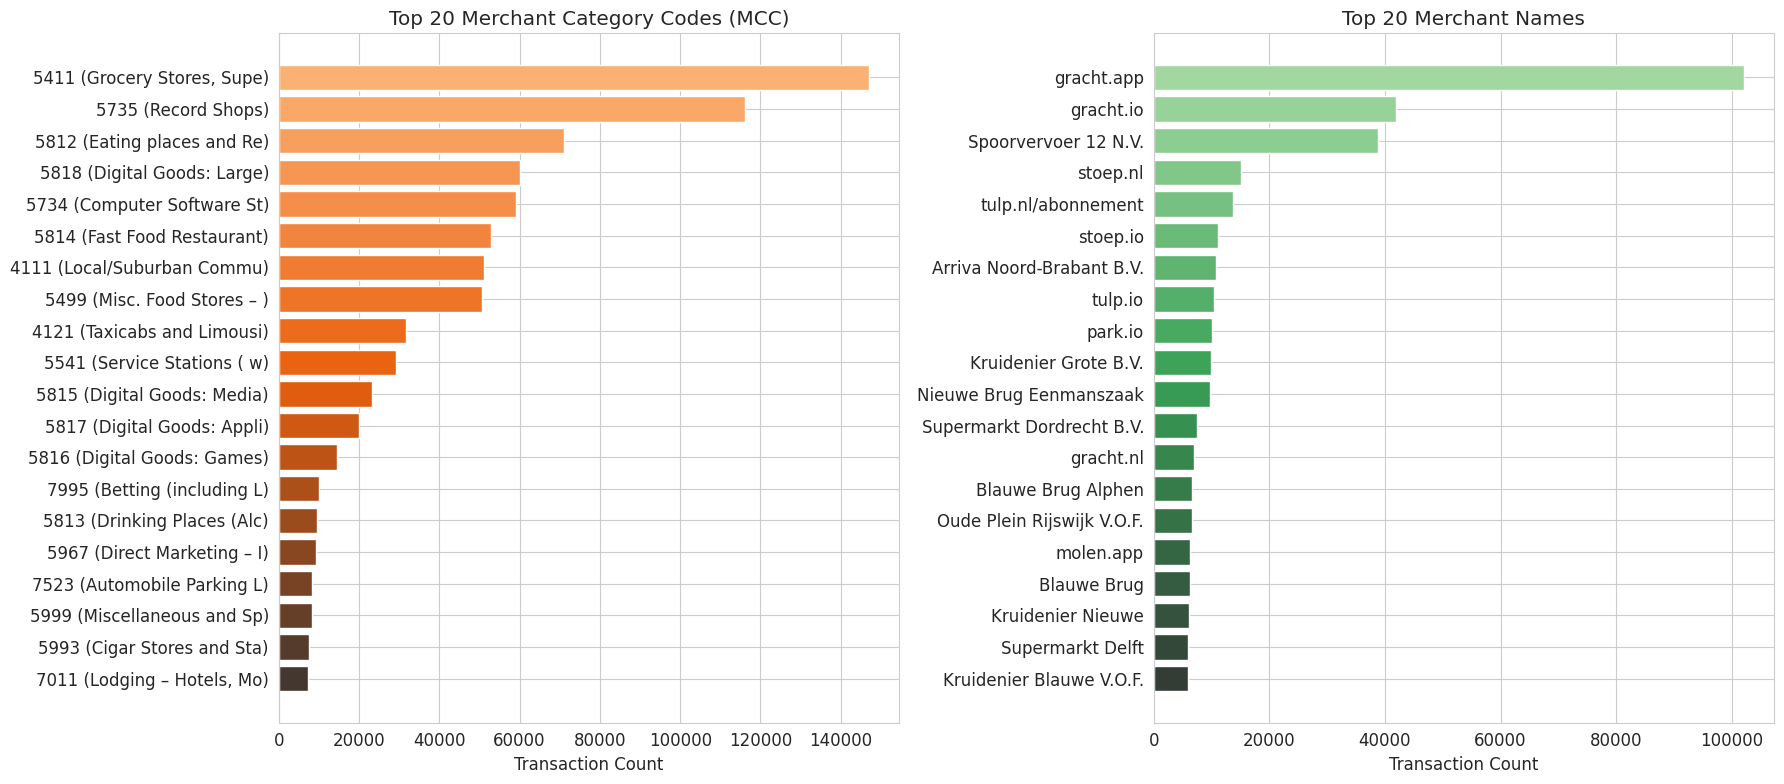

Card Location Distribution:
card_location
DOMESTIC       402043
Not PRESENT    340631
INTER          257326

Domestic (NL merchant) ratio: 40.2%


In [5]:

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Top 20 MCCs by transaction count
mcc_counts = df[df['mcc'].notna()]['mcc'].value_counts().head(20)
mcc_labels = []
for mcc in mcc_counts.index:
    cat = df.loc[df['mcc'] == mcc, 'category'].dropna().head(1)
    label = f"{mcc} ({cat.values[0][:20]})" if len(cat) > 0 else str(mcc)
    mcc_labels.append(label)

axes[0].barh(range(len(mcc_counts)), mcc_counts.values,
             color=sns.color_palette("Oranges_d", len(mcc_counts)))
axes[0].set_yticks(range(len(mcc_counts)))
axes[0].set_yticklabels(mcc_labels)
axes[0].set_title('Top 20 Merchant Category Codes (MCC)')
axes[0].set_xlabel('Transaction Count')
axes[0].invert_yaxis()

# Top 20 merchant names
merchant_counts = df[df['transaction_merchants_name'].notna()]['transaction_merchants_name'].value_counts().head(20)
axes[1].barh(range(len(merchant_counts)), merchant_counts.values,
             color=sns.color_palette("Greens_d", len(merchant_counts)))
axes[1].set_yticks(range(len(merchant_counts)))
axes[1].set_yticklabels(merchant_counts.index)
axes[1].set_title('Top 20 Merchant Names')
axes[1].set_xlabel('Transaction Count')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

# DOMESTIC vs INTER breakdown
print("Card Location Distribution:")
print(df['card_location'].value_counts().to_string())
print(f"\nDomestic (NL merchant) ratio: {(df['card_location'] == 'DOMESTIC').mean():.1%}")


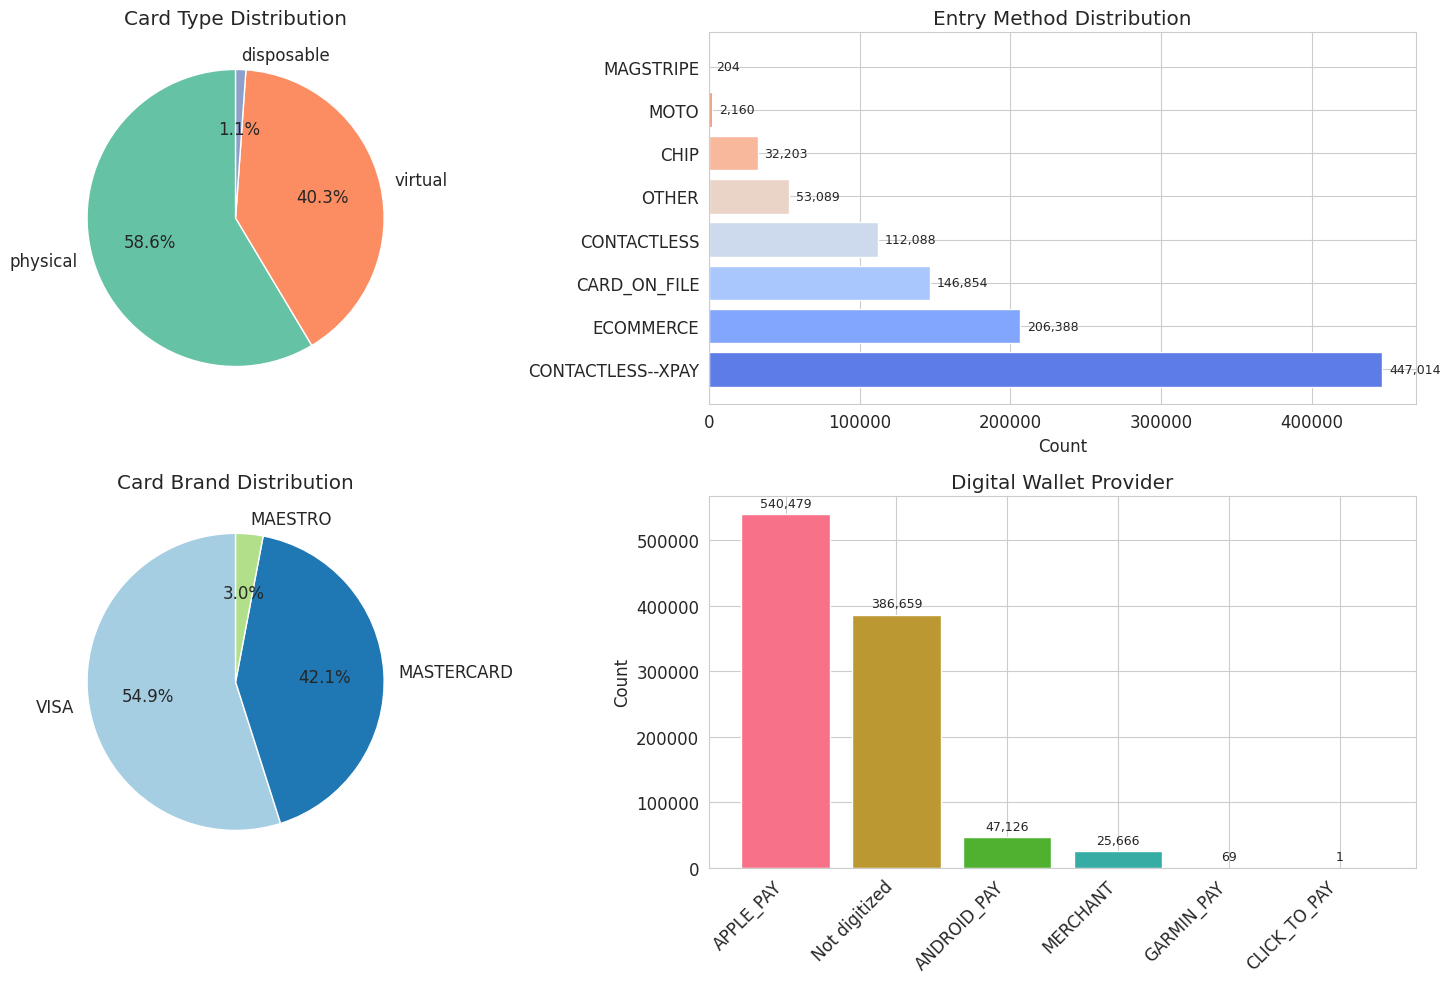

In [6]:

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Card type distribution
ct = df['card_type'].value_counts()
axes[0, 0].pie(ct.values, labels=ct.index, autopct='%1.1f%%',
               colors=sns.color_palette("Set2", len(ct)), startangle=90)
axes[0, 0].set_title('Card Type Distribution')

# Entry method distribution
em = df['entry_method'].value_counts().head(8)
axes[0, 1].barh(em.index, em.values, color=sns.color_palette("coolwarm", len(em)))
axes[0, 1].set_title('Entry Method Distribution')
axes[0, 1].set_xlabel('Count')
for i, v in enumerate(em.values):
    axes[0, 1].text(v + em.values[0]*0.01, i, f'{v:,}', va='center', fontsize=9)

# Card brand distribution
cb = df['card_brand'].value_counts()
axes[1, 0].pie(cb.values, labels=cb.index, autopct='%1.1f%%',
               colors=sns.color_palette("Paired", len(cb)), startangle=90)
axes[1, 0].set_title('Card Brand Distribution')

# Digital provider distribution
dp = df['digitized_provider'].value_counts()
axes[1, 1].bar(range(len(dp)), dp.values, color=sns.color_palette("husl", len(dp)))
axes[1, 1].set_title('Digital Wallet Provider')
axes[1, 1].set_ylabel('Count')
axes[1, 1].set_xticks(range(len(dp)))
axes[1, 1].set_xticklabels(dp.index, rotation=45, ha='right')
for i, v in enumerate(dp.values):
    axes[1, 1].text(i, v + dp.values[0]*0.02, f'{v:,}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()


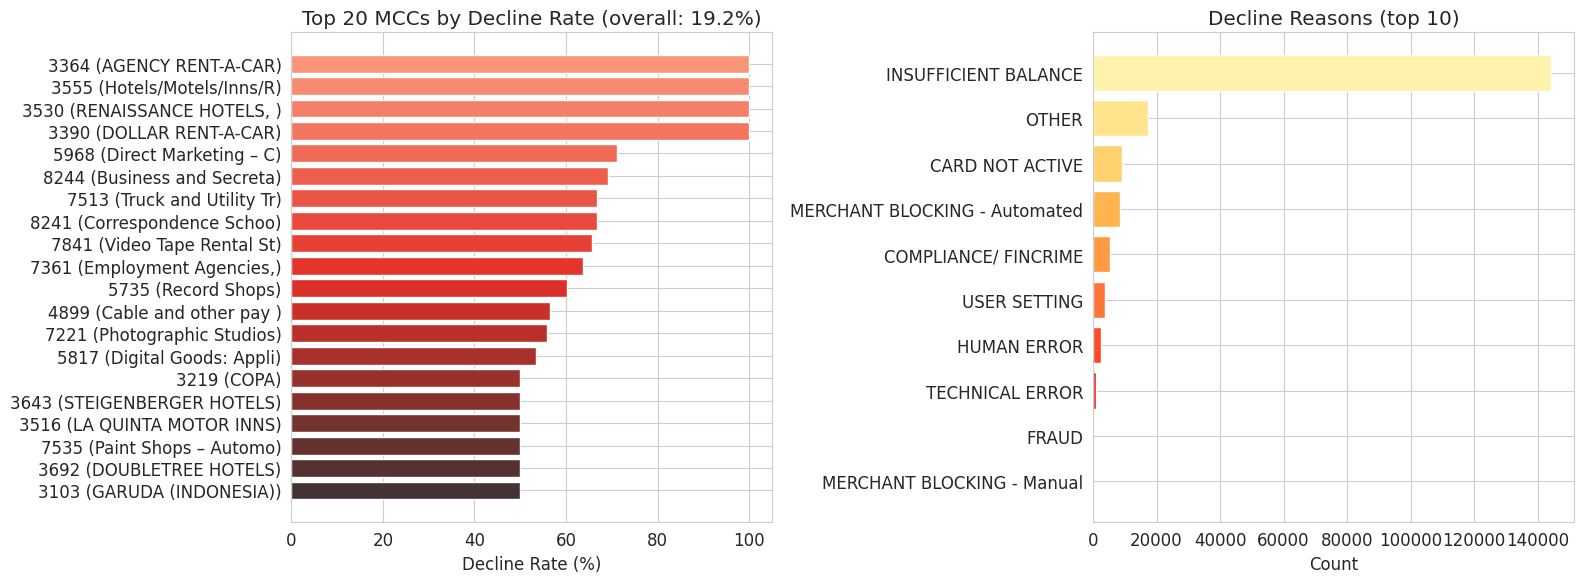

Decline rate by card type:
card_type
disposable     9.1
physical      20.4
virtual       17.8


In [7]:

declined = df[df['state'] == 'DECLINED']
completed = df[df['state'] == 'COMPLETED']
overall_decline_rate = len(declined) / len(df) * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Decline rate by MCC (top 20 MCCs by decline rate)
mcc_total = df[df['mcc'].notna()].groupby('mcc').size()
mcc_declined = declined[declined['mcc'].notna()].groupby('mcc').size()
mcc_decline_rate = (mcc_declined / mcc_total * 100).dropna().sort_values(ascending=False).head(20)

mcc_dr_labels = []
for mcc in mcc_decline_rate.index:
    cat = df.loc[df['mcc'] == mcc, 'category'].dropna().head(1)
    label = f"{mcc} ({cat.values[0][:20]})" if len(cat) > 0 else str(mcc)
    mcc_dr_labels.append(label)

axes[0].barh(range(len(mcc_decline_rate)), mcc_decline_rate.values,
             color=sns.color_palette("Reds_d", len(mcc_decline_rate)))
axes[0].set_yticks(range(len(mcc_decline_rate)))
axes[0].set_yticklabels(mcc_dr_labels)
axes[0].set_title(f'Top 20 MCCs by Decline Rate (overall: {overall_decline_rate:.1f}%)')
axes[0].set_xlabel('Decline Rate (%)')
axes[0].invert_yaxis()

# Decline reasons breakdown
if 'declined_reason_category' in declined.columns:
    reasons = declined['declined_reason_category'].value_counts().head(10)
    axes[1].barh(reasons.index, reasons.values, color=sns.color_palette("YlOrRd", len(reasons)))
    axes[1].set_title('Decline Reasons (top 10)')
    axes[1].set_xlabel('Count')
    axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

# Decline rate by card type
print("Decline rate by card type:")
decline_by_card = df.groupby('card_type')['state'].apply(
    lambda x: (x == 'DECLINED').mean() * 100
).round(1)
print(decline_by_card.to_string())


## Fraud Scenario Labels

The dataset contains **3 labelled fraud scenario patterns** in the `is_fraud_scenario` column (`velocity_attack`, `impossible_travel`, `smurfing`). Note that ~99.97% of rows are null (not labelled as fraud).


## Your Turn

This is your hackathon. The data is synthetic and may contain artifacts - that is expected. Ask your own questions, follow your own curiosity, and build whatever you find interesting
